<a href="https://colab.research.google.com/github/klee6153/my-stock-quant/blob/main/%E7%A6%AA%E5%AD%B8%E8%82%A1%E5%B8%82_%E7%B2%BE%E6%BA%96%E8%A8%BA%E6%96%B7%E7%B3%BB%E7%B5%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38957 (\N{CJK UNIFIED IDEOGRAPH-982D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23616 (\N{CJK UNIFIED IDEOGRAPH-5C40}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


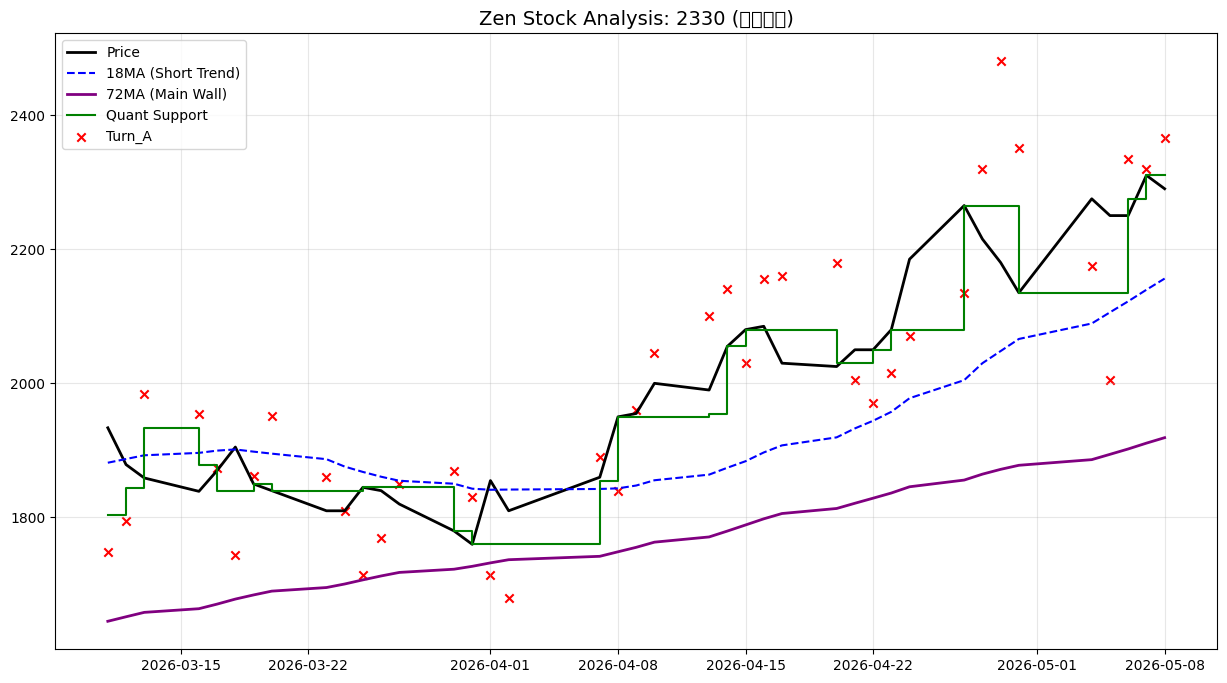

--- 2330 學習診斷報告 ---
最新收盤價：2290.00
量化支撐牆：2310.00
明日轉折 A：2365.00
⚠️ 警告：收盤跌破量化支撐，建議依白皮書執行防禦。


In [ ]:
#@title 禪學股市：2330 實戰診斷系統 { run: "auto" }
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. 設定檔案路徑 (不變更檔名)
target_file = '/content/2330_當年度.txt'

try:
    # 2. 讀取數據 (跳過第二行標籤列)
    df = pd.read_csv(target_file, skiprows=[1])
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    # 3. 指標計算 (數據量已足夠計算 72MA)
    df['18MA'] = df['Close'].rolling(window=18).mean()
    df['72MA'] = df['Close'].rolling(window=72).mean()

    # 轉折 A 預測 (明日壓力/支撐參考)
    df['Turn_A'] = 2 * df['Close'].shift(2) - df['Close'].shift(5)

    # 量化指標 (三日內最大量那天的收盤價)
    def get_quant(idx):
        if idx < 2: return np.nan
        return df.loc[df.loc[idx-2:idx, 'Volume'].idxmax(), 'Close']
    df['Quant'] = df.index.map(get_quant)

    # 4. 格局判定邏輯 [cite: 1]
    last = df.iloc[-1]
    prev = df.iloc[-2]
    is_18_up = last['18MA'] > prev['18MA']
    # 注意：如果數據不滿 72 天，72MA 會是 NaN，這裡做個防錯處理
    is_72_up = last['72MA'] > (df['72MA'].shift(1).iloc[-1]) if not np.isnan(last['72MA']) else True

    status = "多頭格局" if is_18_up and is_72_up else "修正/箱型格局"

    # 5. 繪圖
    plt.figure(figsize=(15, 8))
    plot_df = df.tail(40) # 觀察最近 40 天
    plt.plot(plot_df['Date'], plot_df['Close'], label='Price', color='black', linewidth=2)
    plt.plot(plot_df['Date'], plot_df['18MA'], label='18MA (Short Trend)', color='blue', linestyle='--')
    if not df['72MA'].isnull().all():
        plt.plot(plot_df['Date'], plot_df['72MA'], label='72MA (Main Wall)', color='purple', linewidth=2)
    plt.step(plot_df['Date'], plot_df['Quant'], label='Quant Support', color='green', where='post')
    plt.scatter(plot_df['Date'], plot_df['Turn_A'], color='red', marker='x', label='Turn_A')

    plt.title(f'Zen Stock Analysis: 2330 ({status})', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 6. 精準診斷報告
    print(f"--- 2330 學習診斷報告 ---")
    print(f"最新收盤價：{last['Close']:.2f}")
    print(f"量化支撐牆：{last['Quant']:.2f}")
    print(f"明日轉折 A：{last['Turn_A']:.2f}")

    if last['Close'] > last['Quant']:
        print("✅ 狀態：股價位於量化指標之上，多方控盤。")
    else:
        print("⚠️ 警告：收盤跌破量化支撐，建議依白皮書執行防禦。")

except Exception as e:
    print(f"執行出錯：{e}。請確認 /content/2330_當年度.txt 檔案存在。")